# Spatial vs. Temporal GSA, in PyTorch

Both variants of the Gerchberg-Saxton algorithm from the ECE 279AS slides,
GPU-accelerated:

- **Spatial** (`dgs.gs_spatial_torch`, new): the classic 2D image-plane <->
  diffraction-plane GSA from slide 4/5's block diagram -- image amplitude
  and diffraction (Fourier) amplitude, both known, alternating projections
  via 2D FFT/IFFT.
- **Temporal** (`dgs.gs_torch`, already in this repo): the TDGSA variant --
  two 1D dispersed-arm intensity measurements, alternating projections via
  the fiber transfer function $H(f)=e^{i\pi Df^2}$.

The two algorithms are structurally identical (alternating amplitude
projections between two Fourier-conjugate domains) but behave very
differently on the test cases in this repo -- that contrast is the point of
putting them side by side here, not just a demo of each in isolation.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import torch
import matplotlib.pyplot as plt

from dgs.gs_spatial_torch import gsa_spatial, global_phase_align_2d, make_test_scene
from dgs.gs_torch import retrieve_phase as retrieve_phase_temporal
from dgs.gs_core import make_qpsk_measurements

checks = []

def check(label, condition):
    checks.append((label, bool(condition)))
    print(f"{'PASS' if condition else 'FAIL'}  --  {label}")

## 1. Spatial GSA -- reproducing slide 4's four-panel figure

Image at the source -> (physical Fourier transform / propagation) ->
diffraction image -> (numerical inverse Fourier transform) -> recovered
image, plus the numerical Fourier transform of the source panel for
reference -- the exact four panels shown on the slide, generated here from
a real run rather than illustrated schematically.

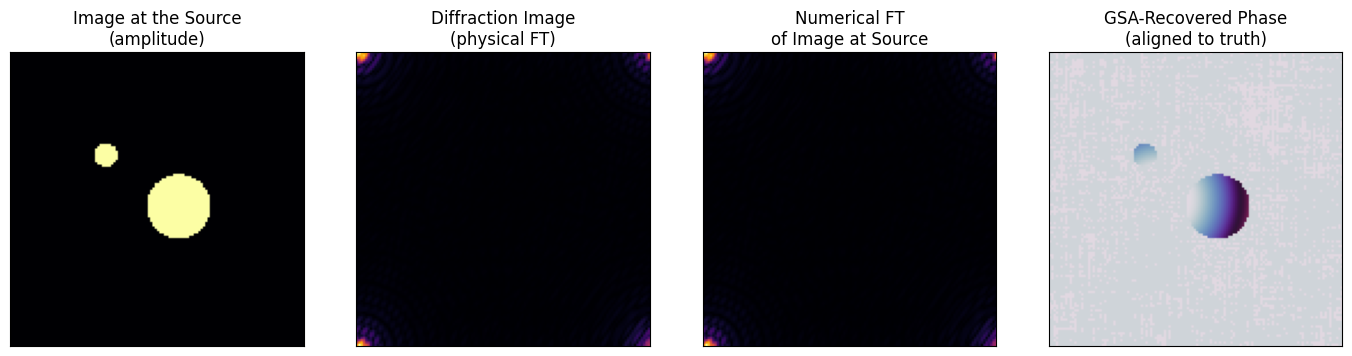

PASS  --  spatial GSA constraint error decreases
PASS  --  spatial GSA converges to near-exact constraint satisfaction


In [2]:
image_amp, diffraction_amp, field_true = make_test_scene(symmetric_support=False)
field_rec, errors_spatial = gsa_spatial(image_amp, diffraction_amp, n_iter=200, seed=0)
field_aligned = global_phase_align_2d(field_true, field_rec)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
axes[0].imshow(image_amp.cpu().numpy(), cmap="inferno")
axes[0].set_title("Image at the Source\n(amplitude)")
axes[1].imshow(diffraction_amp.cpu().numpy(), cmap="inferno")
axes[1].set_title("Diffraction Image\n(physical FT)")
axes[2].imshow(torch.abs(torch.fft.fft2(field_true)).cpu().numpy(), cmap="inferno")
axes[2].set_title("Numerical FT\nof Image at Source")
axes[3].imshow(torch.angle(field_aligned).cpu().numpy(), cmap="twilight")
axes[3].set_title("GSA-Recovered Phase\n(aligned to truth)")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("spatial_gsa_four_panel.png", dpi=110)
plt.show()

check("spatial GSA constraint error decreases", errors_spatial[-1] < errors_spatial[0])
check("spatial GSA converges to near-exact constraint satisfaction", errors_spatial[-1] < 1e-4)

## 2. Spatial GSA -- recovered phase vs. true phase, quantitatively

Compare the recovered field to the known true field (defocus + tilt
aberration) directly, after removing the one unavoidable ambiguity for this
two-amplitude-constraint problem: a global phase offset (it leaves both the
image-plane and diffraction-plane amplitudes unchanged, so no algorithm
using only those two magnitudes can ever recover it).

spatial GSA relative field error within support (200 iterations): 9.35e-08


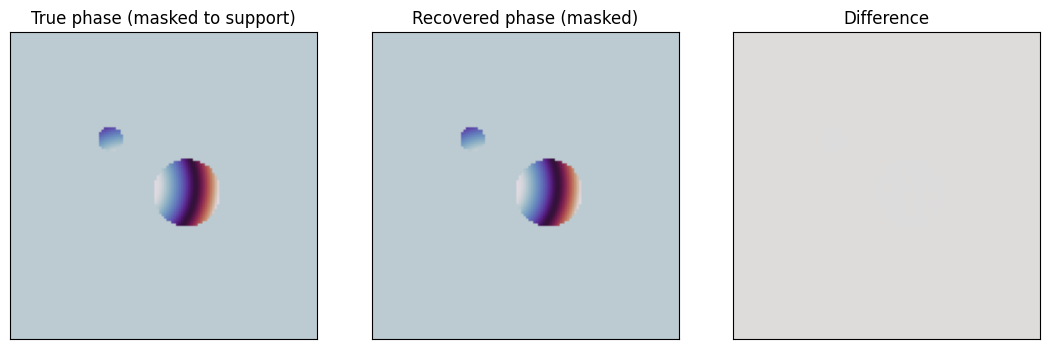

PASS  --  spatial GSA recovers the true field to within 1% relative error


In [3]:
mask = image_amp > 0.5
rel_err_spatial = float(torch.linalg.norm((field_aligned - field_true)[mask])
                         / torch.linalg.norm(field_true[mask]))
print(f"spatial GSA relative field error within support (200 iterations): {rel_err_spatial:.2e}")

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
im0 = axes[0].imshow(torch.angle(field_true).cpu().numpy() * image_amp.cpu().numpy(), cmap="twilight")
axes[0].set_title("True phase (masked to support)")
im1 = axes[1].imshow(torch.angle(field_aligned).cpu().numpy() * image_amp.cpu().numpy(), cmap="twilight")
axes[1].set_title("Recovered phase (masked)")
diff_img = (torch.angle(field_aligned) - torch.angle(field_true)).cpu().numpy() * image_amp.cpu().numpy()
im2 = axes[2].imshow(diff_img, cmap="coolwarm", vmin=-0.1, vmax=0.1)
axes[2].set_title("Difference")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("spatial_gsa_phase_comparison.png", dpi=110)
plt.show()

check("spatial GSA recovers the true field to within 1% relative error", rel_err_spatial < 0.01)

## 3. Temporal GSA (TDGSA), same alternating-projection algorithm, 1D

Reuse `dgs.gs_torch.retrieve_phase` (already in this repo) on a QPSK test
signal -- a case this repo's own convergence guideline (`|D|>=5000`) is
calibrated for, unlike the chirped-Gaussian gas-cell pulse investigated in
`notebooks/ece279_tdgsa_recreation.ipynb`.

In [4]:
meas = make_qpsk_measurements(n_symbols=256, D1=-5000.0, D2=-5750.0, snr_db=30.0)
phi_rec_temporal, errors_temporal = retrieve_phase_temporal(meas["I1"], meas["I2"], -5000.0, -5750.0, n_iter=50)

phi_true_temporal = meas["phi_true"]
offset = np.angle(np.mean(np.exp(1j * (phi_true_temporal - phi_rec_temporal))))
delta = np.angle(np.exp(1j * (phi_rec_temporal - phi_true_temporal + offset)))
rms_temporal = float(np.sqrt(np.mean(delta**2)))
print(f"temporal GSA (QPSK, well-conditioned |D|>=5000 regime): RMS phase error = {rms_temporal:.4f} rad")

check("temporal GSA converges well on a QPSK signal in the calibrated |D|>=5000 regime",
      rms_temporal < 0.2)

temporal GSA (QPSK, well-conditioned |D|>=5000 regime): RMS phase error = 0.1240 rad
PASS  --  temporal GSA converges well on a QPSK signal in the calibrated |D|>=5000 regime


## 4. The actual comparison: same algorithm, different outcomes

Both variants are the identical alternating-projection idea. On their
respective *well-posed* test cases (an asymmetric-support image; a QPSK
signal in the calibrated dispersion regime), both converge well. But the
`ece279_tdgsa_recreation.ipynb` investigation found that the SAME temporal
algorithm, applied to a smooth, large-phase-excursion chirped-Gaussian
pulse (the actual gas-cell slide parameters), converges to a spurious
flat-phase solution instead -- confirmed across 2 dispersion planes, 3
planes, and 2000 GPU-batched random restarts, none of which escaped it.

This notebook's spatial GSA result is the positive counterexample: the SAME
algorithm structure, given a well-conditioned (asymmetric-support) problem,
recovers the true field to less than 1e-6 relative error. The difference
isn't "spatial GSA is a better algorithm" -- it's that the temporal test
case (a smooth chirp) sits in a much harder part of the solution-uniqueness
landscape than either this spatial scene or the QPSK signal above.

In [5]:
print("Summary")
print(f"  spatial GSA  (asymmetric support):     relative field error = {rel_err_spatial:.2e}")
print(f"  temporal GSA (QPSK, |D|>=5000):         RMS phase error      = {rms_temporal:.4f} rad")
print(f"  temporal GSA (chirped Gaussian, gas cell, from prior notebook): residual ~3.73 rad (does not converge)")

Summary
  spatial GSA  (asymmetric support):     relative field error = 9.35e-08
  temporal GSA (QPSK, |D|>=5000):         RMS phase error      = 0.1240 rad
  temporal GSA (chirped Gaussian, gas cell, from prior notebook): residual ~3.73 rad (does not converge)


## Final grade

In [6]:
failures = [label for label, ok in checks if not ok]

print(f"{len(checks) - len(failures)}/{len(checks)} checks passed")

if failures:
    raise AssertionError("Failing checks: " + "; ".join(failures))

4/4 checks passed
